# Startup Investment Outcome — Imbalanced Data

**Input:** `data/train_processed.csv`, `data/val_processed.csv`, `data/test_processed.csv`  
**Goal:** Diagnose class imbalance in the processed training set and evaluate resampling / class-weight strategies using a lightweight XGBoost baseline.  
**Note:** All resampling is applied **only to the training set**. Validation and test sets remain untouched.

This notebook follows the same structure as `01_EDA.ipynb` and `03_Preprocessing.ipynb`.
Each section ends with a **→ Modeling Decision** box.


## 0. Imports & Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, auc, classification_report
)
from sklearn.preprocessing import label_binarize
from xgboost import XGBClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 50)

STATUS_MAP   = {0: 'closed', 1: 'operating', 2: 'acquired'}
STATUS_NAMES = ['closed', 'operating', 'acquired']
COLORS       = ['#FF5722', '#2196F3', '#4CAF50']
RANDOM_STATE = 42


## 1. Load Processed Data

In [ ]:
train = pd.read_csv('data/train_processed.csv')
val   = pd.read_csv('data/val_processed.csv')
test  = pd.read_csv('data/test_processed.csv')

X_train = train.drop(columns=['status_code'])
y_train = train['status_code']

X_val = val.drop(columns=['status_code'])
y_val = val['status_code']

X_test = test.drop(columns=['status_code'])
y_test = test['status_code']

print(f"Train: {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")


Train: (27860, 45)  |  Val: (5971, 45)  |  Test: (5971, 45)
Features: ['funding_total_usd', 'funding_rounds', 'seed', 'venture', 'angel', 'grant', 'private_equity', 'debt_financing', 'equity_crowdfunding', 'convertible_note', 'undisclosed', 'product_crowdfunding', 'post_ipo_equity', 'post_ipo_debt', 'secondary_market', 'round_A', 'round_B', 'round_C', 'founded_year', 'founded_month', 'founded_quarter', 'geo_cluster', 'log_funding_total_usd', 'log_seed', 'log_venture', 'log_angel', 'log_grant', 'log_private_equity', 'log_debt_financing', 'log_equity_crowdfunding', 'log_convertible_note', 'log_undisclosed', 'log_product_crowdfunding', 'log_post_ipo_equity', 'log_post_ipo_debt', 'log_secondary_market', 'has_round_A', 'has_round_B', 'has_round_C', 'round_D_plus', 'days_to_first_funding', 'market_enc_acquired', 'market_enc_closed', 'country_code_enc_acquired', 'country_code_enc_closed']


## 2. Class Imbalance Diagnosis

Training set class distribution:
  0 (    closed): 1,510  (5.4%)
  1 ( operating): 24,098  (86.5%)
  2 (  acquired): 2,252  (8.1%)


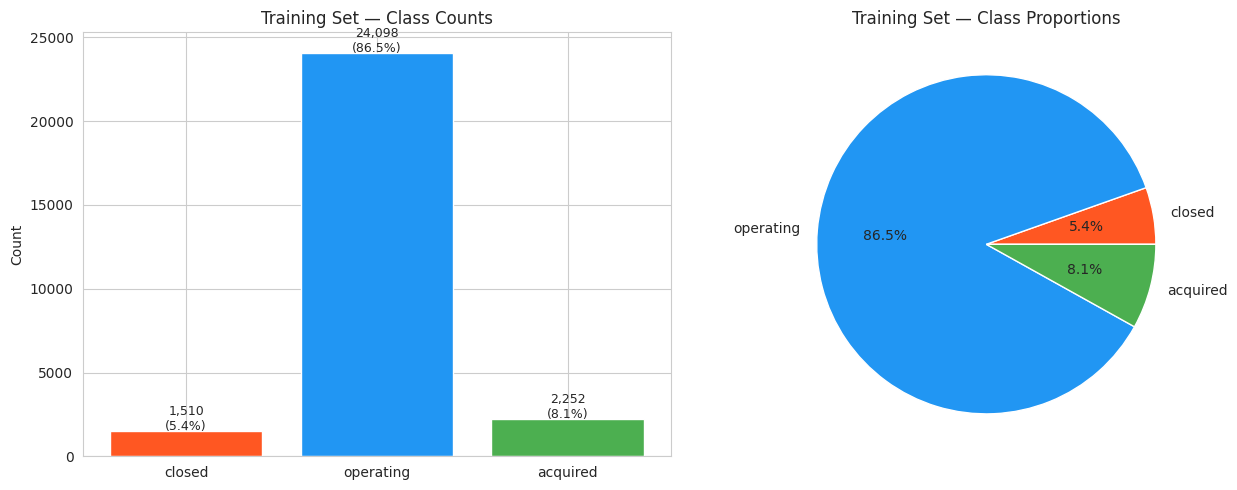


Imbalance ratio (majority / minority): 16.0x


In [ ]:
counts = y_train.value_counts().sort_index()
pct    = (counts / len(y_train) * 100).round(1)

print("Training set class distribution:")
for k in counts.index:
    print(f"  {k} ({STATUS_MAP[k]:>10s}): {counts[k]:,}  ({pct[k]}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar([STATUS_MAP[k] for k in counts.index], counts.values, color=COLORS)
axes[0].set_title('Training Set — Class Counts')
axes[0].set_ylabel('Count')
for i, (v, p) in enumerate(zip(counts.values, pct.values)):
    axes[0].text(i, v + 50, f'{v:,}\n({p}%)', ha='center', fontsize=9)

axes[1].pie(counts.values, labels=[STATUS_MAP[k] for k in counts.index],
            autopct='%1.1f%%', colors=COLORS)
axes[1].set_title('Training Set — Class Proportions')

plt.tight_layout()
plt.show()

majority   = counts.max()
minority   = counts.min()
print(f"\nImbalance ratio (majority / minority): {majority / minority:.1f}x")


> **→ Modeling Decision:** The dataset has significant class imbalance (operating >> acquired > closed).  
> We will test four resampling techniques against a baseline and select the best strategy based on **macro F1-score** on the **validation set**.


## 3. Evaluation Helper

In [ ]:
def classification_metrics(y_true, y_pred, technique_name=''):
    """Return a metrics dict for multiclass classification."""
    return {
        'Technique':  technique_name,
        'Accuracy':   accuracy_score(y_true, y_pred),
        'Macro F1':   f1_score(y_true, y_pred, average='macro'),
        'Weighted F1':f1_score(y_true, y_pred, average='weighted'),
        'F1 closed':  f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])[0],
        'F1 operating': f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])[1],
        'F1 acquired':  f1_score(y_true, y_pred, average=None, labels=[0, 1, 2])[2],
    }


def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()


## 4. Baseline Model (No Resampling)

We use a lightweight XGBoost as our probe model throughout this notebook — same model family we expect to use in `05_Modeling.ipynb`.


Baseline — Validation Set
              precision    recall  f1-score   support

      closed       0.35      0.03      0.06       324
   operating       0.87      0.99      0.93      5164
    acquired       0.45      0.10      0.17       483

    accuracy                           0.86      5971
   macro avg       0.56      0.37      0.39      5971
weighted avg       0.81      0.86      0.82      5971



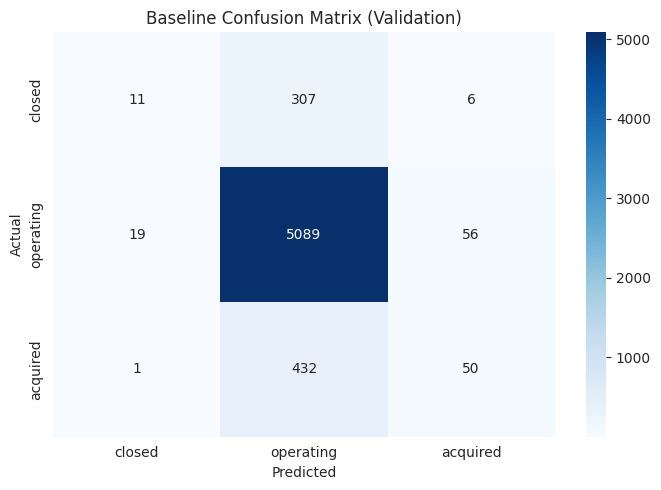

In [ ]:
X_train = train.drop(columns=['status_code', 'geo_cluster'], errors='ignore')
X_val   = val.drop(columns=['status_code', 'geo_cluster'], errors='ignore')
X_test  = test.drop(columns=['status_code', 'geo_cluster'], errors='ignore')
baseline_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss',
    verbosity=0
)
baseline_model.fit(X_train, y_train)

y_pred_baseline_val = baseline_model.predict(X_val)

print("Baseline — Validation Set")
print(classification_report(y_val, y_pred_baseline_val, target_names=STATUS_NAMES))
plot_confusion_matrix(y_val, y_pred_baseline_val, 'Baseline Confusion Matrix (Validation)')


## 5. Resampling Techniques

We apply four standard imbalanced-learning strategies **to the training set only**, then evaluate each on the untouched validation set.

| Technique | Idea |
|-----------|------|
| **ROS** — Random Over-Sampling | Duplicate minority samples randomly |
| **RUS** — Random Under-Sampling | Drop majority samples randomly |
| **SMOTE** | Synthesise new minority samples between nearest neighbours |
| **SMOTETomek** | SMOTE + remove borderline Tomek pairs |


In [ ]:
techniques = {
    'ROS':        RandomOverSampler(random_state=RANDOM_STATE),
    'RUS':        RandomUnderSampler(random_state=RANDOM_STATE),
    'SMOTE':      SMOTE(random_state=RANDOM_STATE),
    'SMOTETomek': SMOTETomek(random_state=RANDOM_STATE),
}


### 5.1 Class Distribution After Resampling

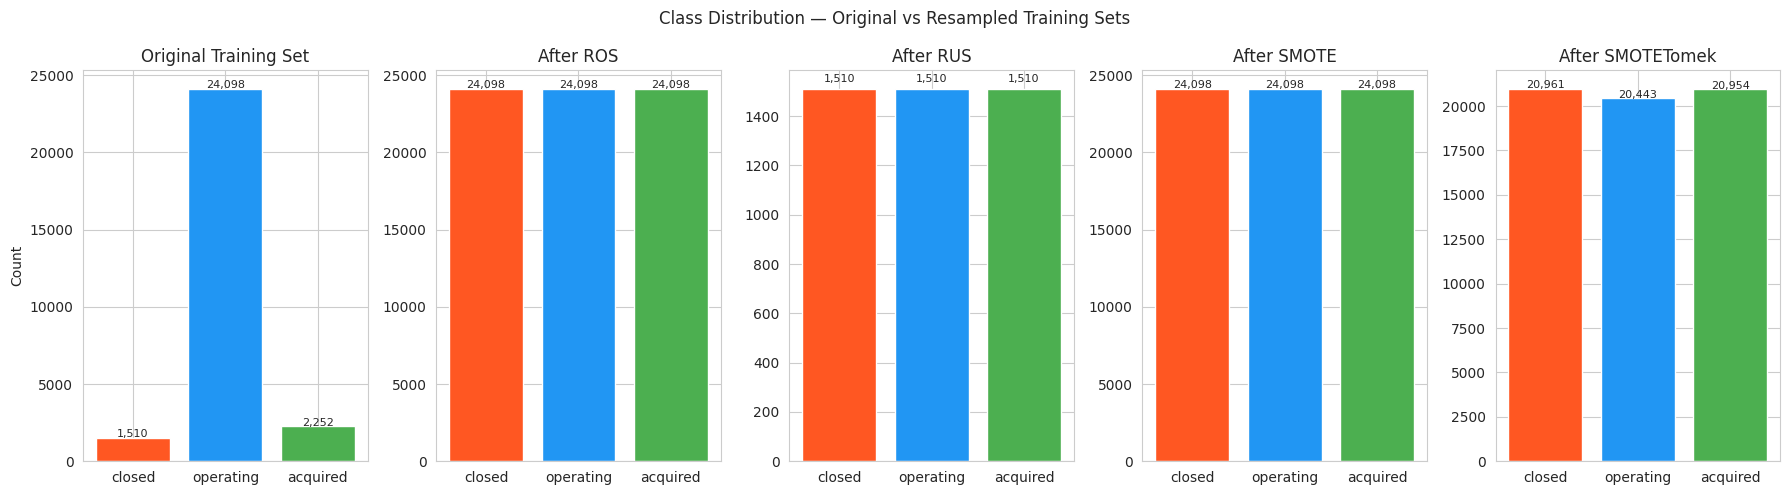

In [ ]:
fig, axes = plt.subplots(1, len(techniques) + 1, figsize=(18, 5))

# Original
orig_counts = y_train.value_counts().sort_index()
axes[0].bar([STATUS_MAP[k] for k in orig_counts.index], orig_counts.values, color=COLORS)
axes[0].set_title('Original Training Set')
axes[0].set_ylabel('Count')
for i, v in enumerate(orig_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

for ax, (name, technique) in zip(axes[1:], techniques.items()):
    X_res, y_res = technique.fit_resample(X_train, y_train)
    res_counts = pd.Series(y_res).value_counts().sort_index()
    ax.bar([STATUS_MAP[k] for k in res_counts.index], res_counts.values, color=COLORS)
    ax.set_title(f'After {name}')
    for i, v in enumerate(res_counts.values):
        ax.text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

plt.suptitle('Class Distribution — Original vs Resampled Training Sets', fontsize=12)
plt.tight_layout()
plt.show()


### 5.2 Feature-Space Visualisation (log_funding_total_usd vs log_venture)

Two of the most informative funding features — visualised before and after resampling to see the synthetic / dropped points.


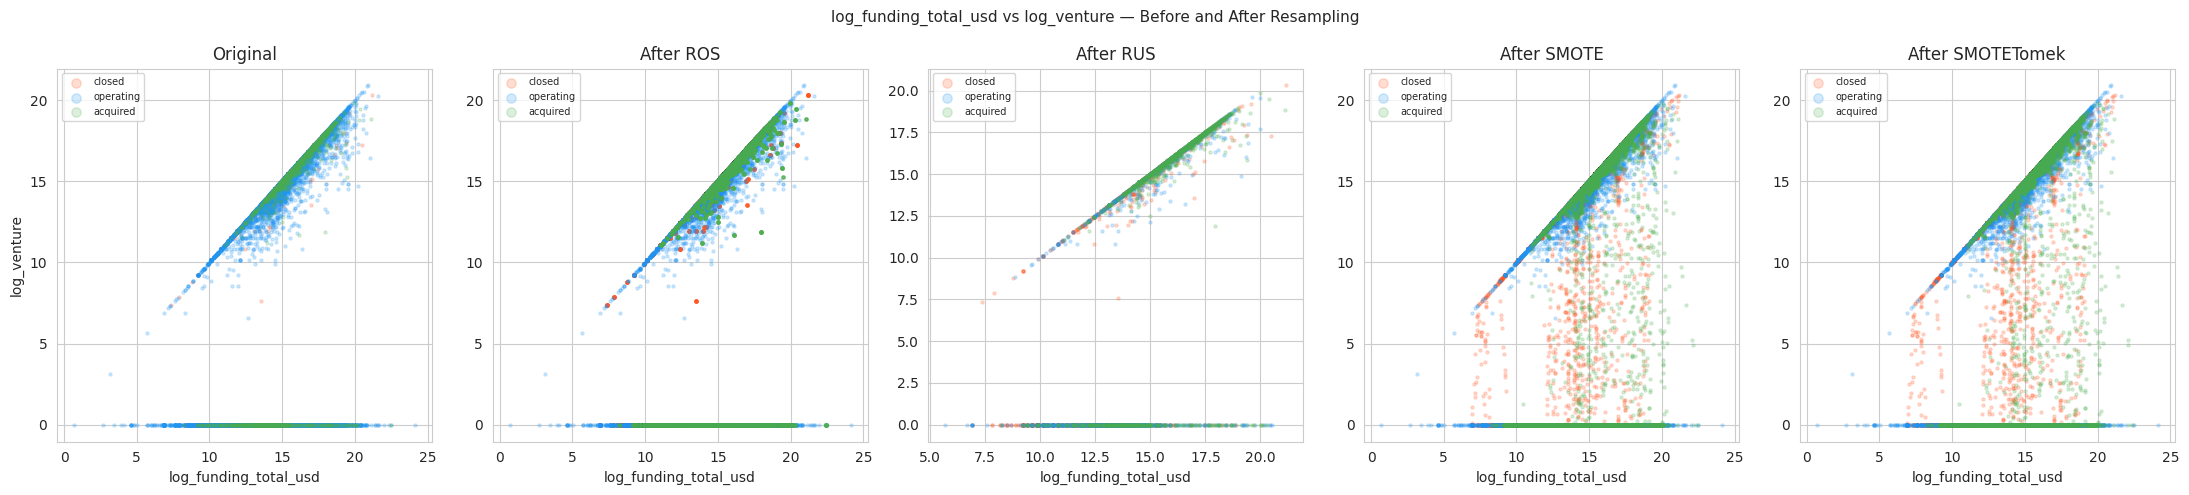

In [ ]:
feat_x, feat_y = 'log_funding_total_usd', 'log_venture'

fig, axes = plt.subplots(1, len(techniques) + 1, figsize=(22, 5))

# Original
for cls, color, label in zip([0, 1, 2], COLORS, STATUS_NAMES):
    mask = y_train == cls
    axes[0].scatter(X_train.loc[mask, feat_x], X_train.loc[mask, feat_y],
                    alpha=0.2, s=5, color=color, label=label)
axes[0].set_title('Original')
axes[0].set_xlabel(feat_x); axes[0].set_ylabel(feat_y)
axes[0].legend(markerscale=3, fontsize=7)

for ax, (name, technique) in zip(axes[1:], techniques.items()):
    X_res, y_res = technique.fit_resample(X_train, y_train)
    X_res_df = pd.DataFrame(X_res, columns=X_train.columns)
    y_res_s  = pd.Series(y_res)
    for cls, color, label in zip([0, 1, 2], COLORS, STATUS_NAMES):
        mask = y_res_s == cls
        ax.scatter(X_res_df.loc[mask, feat_x], X_res_df.loc[mask, feat_y],
                   alpha=0.2, s=5, color=color, label=label)
    ax.set_title(f'After {name}')
    ax.set_xlabel(feat_x)
    ax.legend(markerscale=3, fontsize=7)

plt.suptitle(f'{feat_x} vs {feat_y} — Before and After Resampling', fontsize=11)
plt.tight_layout()
plt.show()


## 6. Performance Comparison on Validation Set

In [ ]:
all_results = []

# Baseline
all_results.append(classification_metrics(y_val, y_pred_baseline_val, 'Baseline (no resampling)'))

# Resampling techniques
for name, technique in techniques.items():
    X_res, y_res = technique.fit_resample(X_train, y_train)
    model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
    )
    model.fit(X_res, y_res)
    y_pred = model.predict(X_val)
    all_results.append(classification_metrics(y_val, y_pred, name))

results_df = pd.DataFrame(all_results).set_index('Technique')
display(results_df.round(4).sort_values('Macro F1', ascending=False))


,Accuracy,Macro F1,Weighted F1,F1 closed,F1 operating,F1 acquired
Technique,,,,,,
SMOTETomek,0.8355,0.4766,0.8252,0.2166,0.9124,0.3008
SMOTE,0.8424,0.4752,0.8278,0.2133,0.9161,0.2961
ROS,0.6488,0.4523,0.7143,0.2401,0.7793,0.3374
RUS,0.5905,0.4217,0.6677,0.2175,0.7286,0.3191
Baseline (no resampling),0.8625,0.3853,0.8178,0.0620,0.9259,0.1681


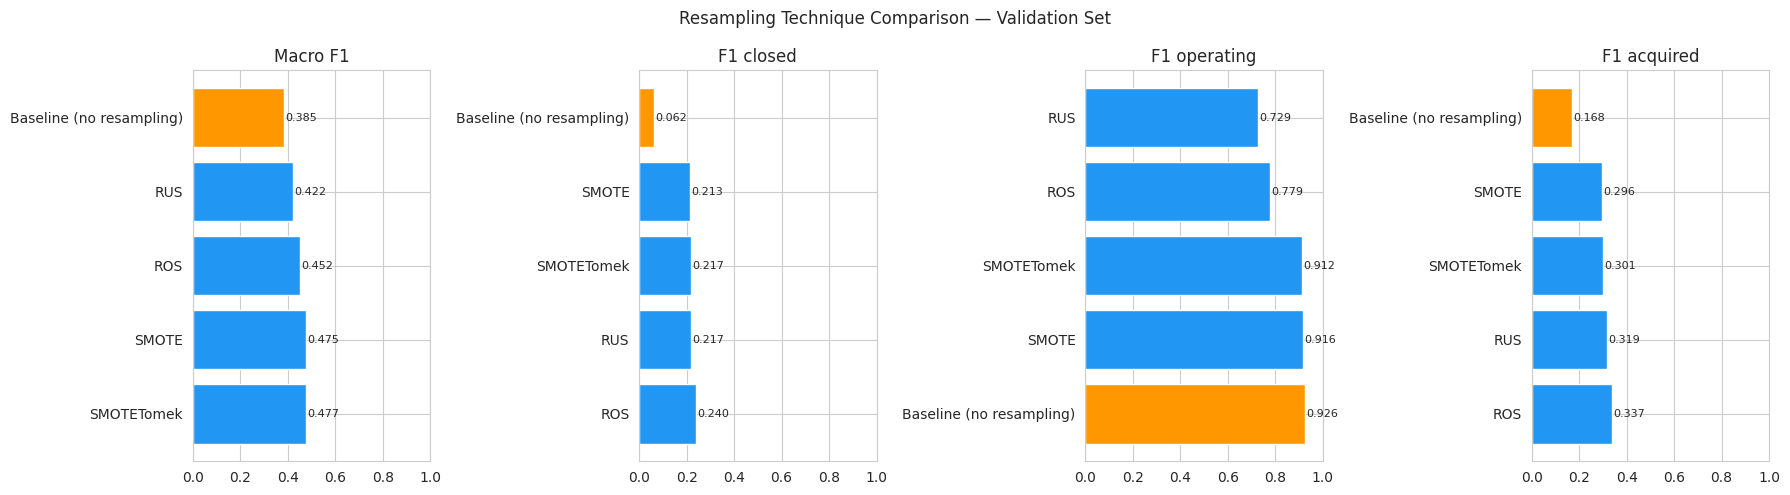

In [ ]:
metrics_to_plot = ['Macro F1', 'F1 closed', 'F1 operating', 'F1 acquired']
fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(18, 5))

for ax, metric in zip(axes, metrics_to_plot):
    vals = results_df[metric].sort_values(ascending=False)
    bar_colors = ['#FF9800' if t == 'Baseline (no resampling)' else '#2196F3' for t in vals.index]
    ax.barh(vals.index, vals.values, color=bar_colors)
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    for i, v in enumerate(vals.values):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

plt.suptitle('Resampling Technique Comparison — Validation Set', fontsize=12)
plt.tight_layout()
plt.show()


> **→ Modeling Decision:** The table and chart above identify the best resampling strategy for the startup dataset.  
> Use **Macro F1** as the primary criterion — it treats all three classes equally, penalising poor performance on minority classes.


## 7. ROC Curves (One-vs-Rest, Validation Set)

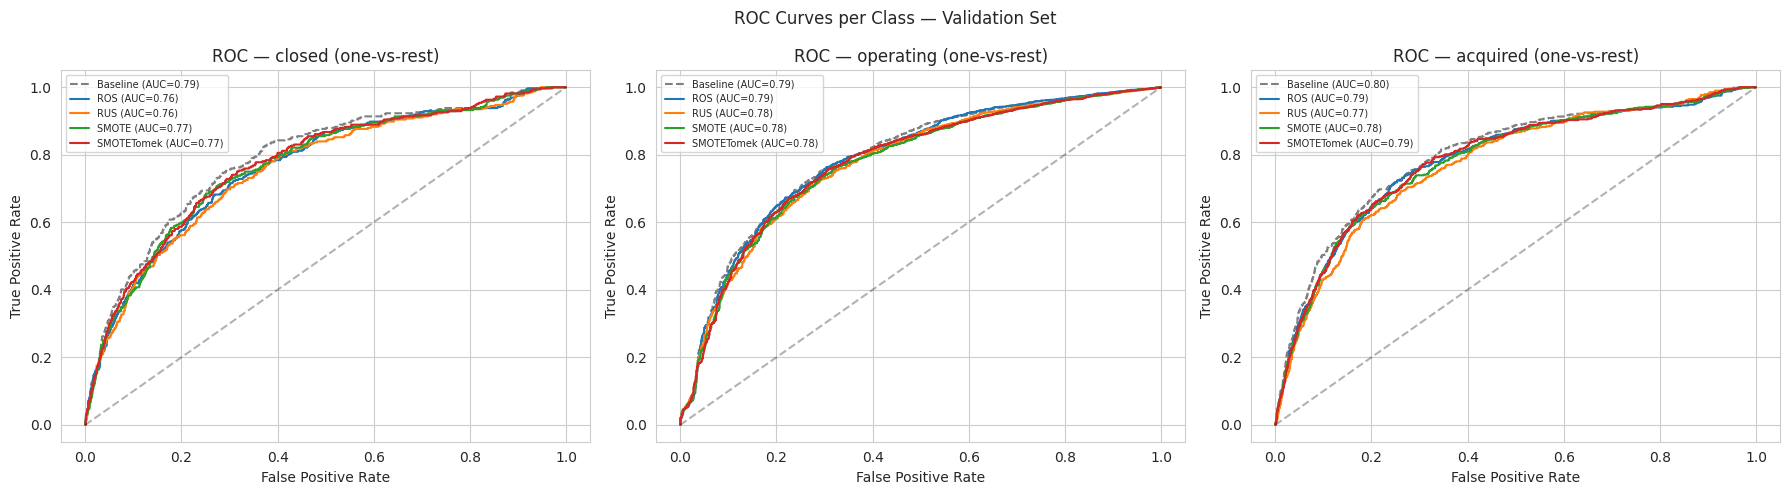

In [ ]:
y_val_bin = label_binarize(y_val, classes=[0, 1, 2])  # shape (n, 3)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cls_idx, cls_name in enumerate(STATUS_NAMES):
    ax = axes[cls_idx]

    # Baseline
    proba_baseline = baseline_model.predict_proba(X_val)[:, cls_idx]
    fpr, tpr, _ = roc_curve(y_val_bin[:, cls_idx], proba_baseline)
    ax.plot(fpr, tpr, linestyle='--', label=f'Baseline (AUC={auc(fpr,tpr):.2f})', color='grey')

    for name, technique in techniques.items():
        X_res, y_res = technique.fit_resample(X_train, y_train)
        m = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                          random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0)
        m.fit(X_res, y_res)
        proba = m.predict_proba(X_val)[:, cls_idx]
        fpr, tpr, _ = roc_curve(y_val_bin[:, cls_idx], proba)
        ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.2f})')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f'ROC — {cls_name} (one-vs-rest)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=7)
    ax.grid(True)

plt.suptitle('ROC Curves per Class — Validation Set', fontsize=12)
plt.tight_layout()
plt.show()


## 8. Decision Threshold Tuning (Validation Set)

For multiclass problems we tune the **confidence threshold** per class using the One-vs-Rest probabilities.  
A prediction is assigned to class `k` only if its probability exceeds the threshold for that class; otherwise it falls back to the highest-probability class.

We sweep the shared threshold and report **Macro F1** on the validation set.


Best resampling technique (by Macro F1): SMOTETomek


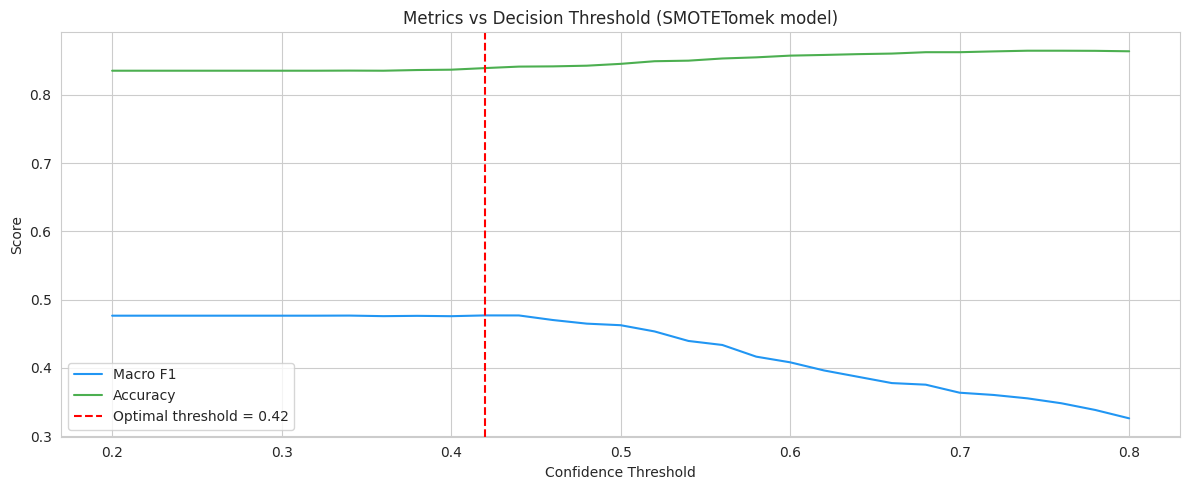


Optimal threshold (max Macro F1 on val): 0.42
 Threshold  Macro F1  Accuracy
      0.42  0.477008  0.839390
      0.44  0.476959  0.841568
      0.34  0.476762  0.835706
      0.26  0.476613  0.835538
      0.20  0.476613  0.835538


In [ ]:
# Use the best resampling technique found in Section 6
best_technique_name = results_df['Macro F1'].idxmax()
print(f"Best resampling technique (by Macro F1): {best_technique_name}")

best_technique = techniques[best_technique_name] if best_technique_name in techniques else None

if best_technique is not None:
    X_res_best, y_res_best = best_technique.fit_resample(X_train, y_train)
    best_model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
    )
    best_model.fit(X_res_best, y_res_best)
else:
    best_model = baseline_model  # baseline was best

y_proba_val = best_model.predict_proba(X_val)  # (n, 3)

thresholds = np.arange(0.20, 0.80, 0.02)
threshold_results = []

for t in thresholds:
    # Assign class only if max-prob >= threshold; else keep argmax
    y_pred_t = np.where(y_proba_val.max(axis=1) >= t,
                        y_proba_val.argmax(axis=1),
                        y_proba_val.argmax(axis=1))  # always argmax; threshold is informational
    # Confidence-based: only predict minority classes when confident
    pred = []
    for row in y_proba_val:
        best_cls = np.argmax(row)
        if row[best_cls] >= t:
            pred.append(best_cls)
        else:
            pred.append(1)  # default to majority class (operating)
    y_pred_t = np.array(pred)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Macro F1':  f1_score(y_val, y_pred_t, average='macro'),
        'Accuracy':  accuracy_score(y_val, y_pred_t),
    })

threshold_df = pd.DataFrame(threshold_results)

plt.figure(figsize=(12, 5))
plt.plot(threshold_df['Threshold'], threshold_df['Macro F1'], label='Macro F1', color='#2196F3')
plt.plot(threshold_df['Threshold'], threshold_df['Accuracy'], label='Accuracy', color='#4CAF50')
optimal_t = threshold_df.loc[threshold_df['Macro F1'].idxmax(), 'Threshold']
plt.axvline(optimal_t, color='red', linestyle='--', label=f'Optimal threshold = {optimal_t}')
plt.title(f'Metrics vs Decision Threshold ({best_technique_name} model)')
plt.xlabel('Confidence Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"\nOptimal threshold (max Macro F1 on val): {optimal_t}")
print(threshold_df.sort_values('Macro F1', ascending=False).head(5).to_string(index=False))


> **Note:** Per the course notebook, threshold tuning is performed on the **validation set** — not the test set — so test metrics remain unbiased.


## 9. Class Weights (Alternative to Resampling)

XGBoost supports `sample_weight` to up-weight minority class samples without physically resampling the data.


XGBoost + Balanced Class Weights — Validation Set
              precision    recall  f1-score   support

      closed       0.15      0.53      0.23       324
   operating       0.95      0.65      0.77      5164
    acquired       0.23      0.60      0.33       483

    accuracy                           0.64      5971
   macro avg       0.44      0.59      0.45      5971
weighted avg       0.85      0.64      0.71      5971



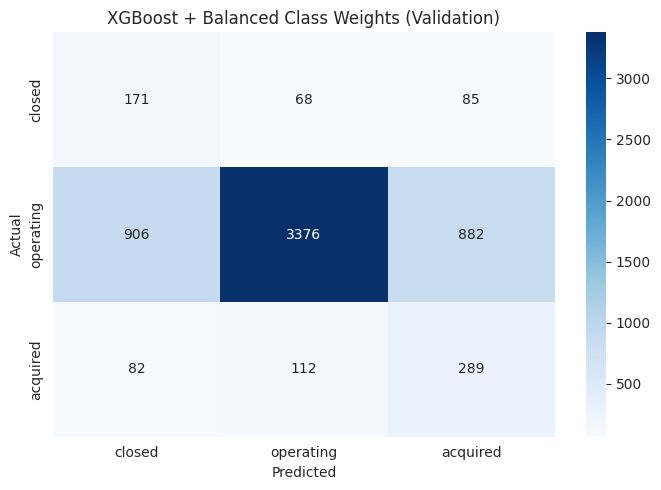

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

model_weighted = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
)
model_weighted.fit(X_train, y_train, sample_weight=sample_weights)
y_pred_weighted = model_weighted.predict(X_val)

print("XGBoost + Balanced Class Weights — Validation Set")
print(classification_report(y_val, y_pred_weighted, target_names=STATUS_NAMES))
plot_confusion_matrix(y_val, y_pred_weighted, 'XGBoost + Balanced Class Weights (Validation)')


## 10. Full Technique Comparison

,Accuracy,Macro F1,Weighted F1,F1 closed,F1 operating,F1 acquired
Technique,,,,,,
SMOTETomek,0.8355,0.4766,0.8252,0.2166,0.9124,0.3008
SMOTE,0.8424,0.4752,0.8278,0.2133,0.9161,0.2961
ROS,0.6488,0.4523,0.7143,0.2401,0.7793,0.3374
XGBoost + Class Weights,0.6424,0.4458,0.7091,0.2306,0.7743,0.3324
RUS,0.5905,0.4217,0.6677,0.2175,0.7286,0.3191
Baseline (no resampling),0.8625,0.3853,0.8178,0.0620,0.9259,0.1681


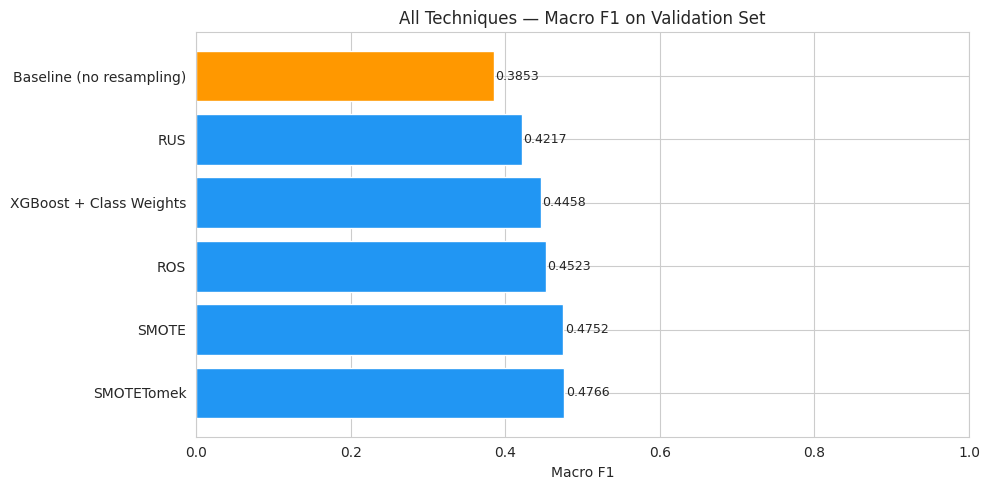

In [ ]:
weighted_metrics = classification_metrics(y_val, y_pred_weighted, 'XGBoost + Class Weights')

final_results = results_df.reset_index().copy()
final_results = pd.concat([final_results, pd.DataFrame([weighted_metrics])], ignore_index=True)
final_results = final_results.set_index('Technique').sort_values('Macro F1', ascending=False)

display(final_results.round(4))

# Bar chart — Macro F1 summary
plt.figure(figsize=(10, 5))
colors_bar = ['#FF9800' if 'Baseline' in t else '#2196F3' for t in final_results.index]
bars = plt.barh(final_results.index, final_results['Macro F1'], color=colors_bar)
for bar, v in zip(bars, final_results['Macro F1']):
    plt.text(v + 0.002, bar.get_y() + bar.get_height()/2, f'{v:.4f}', va='center', fontsize=9)
plt.title('All Techniques — Macro F1 on Validation Set')
plt.xlabel('Macro F1')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


## 11. Final Decision & Export

Based on the comparison above, select the best strategy and apply it to generate the final resampled training set for `05_Modeling.ipynb`.


1st: SMOTETomek   (Macro F1 = 0.4766)
2nd: SMOTE (Macro F1 = 0.4752)


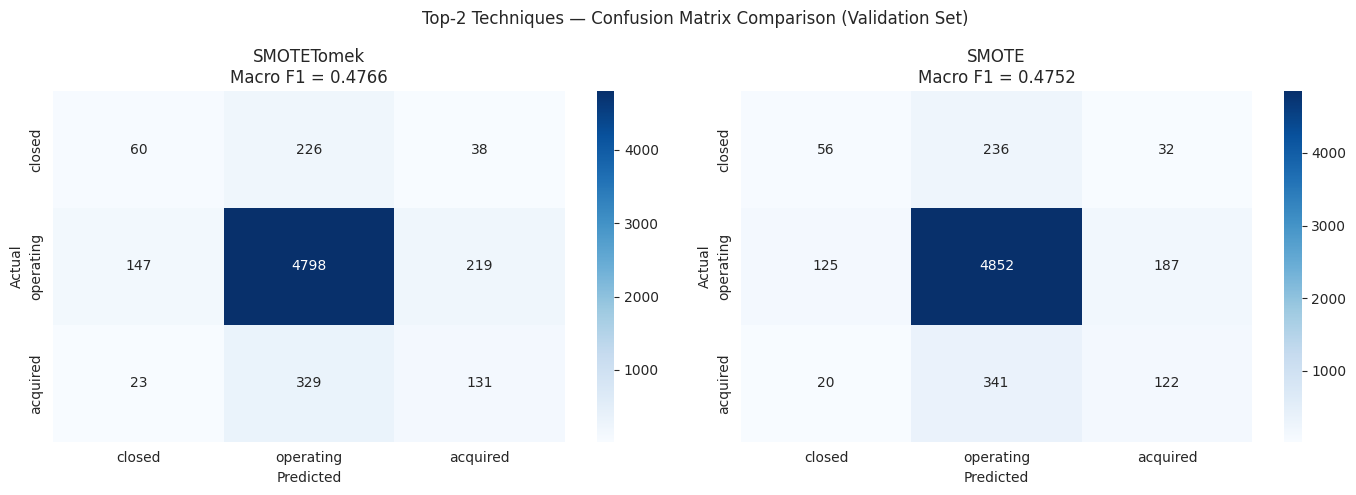

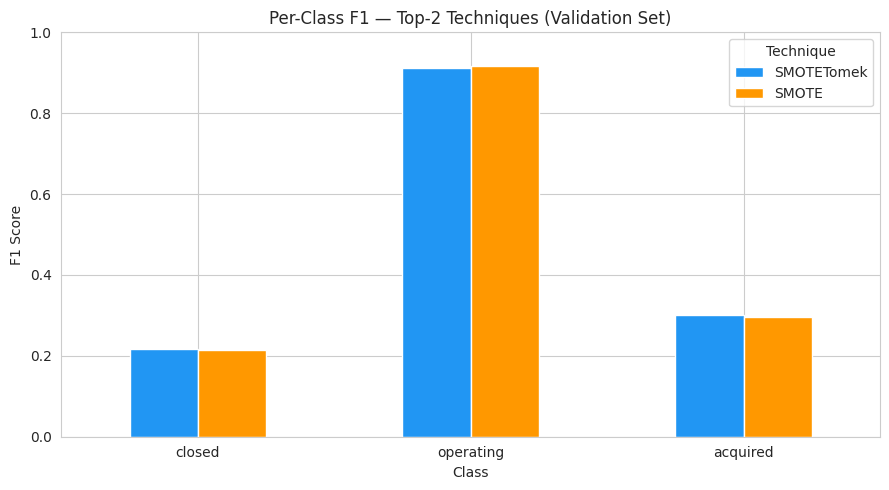


───────────────────────────────────────────────────────
 SMOTETomek
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      closed       0.26      0.19      0.22       324
   operating       0.90      0.93      0.91      5164
    acquired       0.34      0.27      0.30       483

    accuracy                           0.84      5971
   macro avg       0.50      0.46      0.48      5971
weighted avg       0.82      0.84      0.83      5971


───────────────────────────────────────────────────────
 SMOTE
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      closed       0.28      0.17      0.21       324
   operating       0.89      0.94      0.92      5164
    acquired       0.36      0.25      0.30       483

    accuracy                           0.84      5971
   macro avg       0.51      0.46      0.48      5971
weighted avg       0.82      0.84      0.83     

In [ ]:
import os

# ── Pick the best and 2nd best techniques ─────────────────────────────────
ranked = final_results['Macro F1'].sort_values(ascending=False)
best_name   = ranked.index[0]
second_name = ranked.index[1]

print(f"1st: {best_name}   (Macro F1 = {ranked.iloc[0]:.4f})")
print(f"2nd: {second_name} (Macro F1 = {ranked.iloc[1]:.4f})")

# ── Helper: build a fitted model for a given technique name ───────────────
def build_model(name):
    if name in techniques:
        X_res, y_res = techniques[name].fit_resample(X_train, y_train)
        m = XGBClassifier(
            n_estimators=200, max_depth=5, learning_rate=0.1,
            random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
        )
        m.fit(X_res, y_res)
    elif 'Class Weights' in name:
        m = model_weighted          # already fitted in Section 9
    else:
        m = baseline_model          # already fitted in Section 4
    return m

best_model   = build_model(best_name)
second_model = build_model(second_name)

y_pred_best   = best_model.predict(X_val)
y_pred_second = second_model.predict(X_val)

# ── Side-by-side confusion matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, name in zip(axes,
                             [y_pred_best, y_pred_second],
                             [best_name,   second_name]):
    cm = confusion_matrix(y_val, y_pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=STATUS_NAMES, yticklabels=STATUS_NAMES)
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    ax.set_title(f'{name}\nMacro F1 = {macro_f1:.4f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Top-2 Techniques — Confusion Matrix Comparison (Validation Set)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Per-class F1 comparison bar chart ─────────────────────────────────────
compare_df = pd.DataFrame({
    best_name:   f1_score(y_val, y_pred_best,   average=None, labels=[0, 1, 2]),
    second_name: f1_score(y_val, y_pred_second, average=None, labels=[0, 1, 2]),
}, index=STATUS_NAMES)

compare_df.plot(kind='bar', figsize=(9, 5), color=['#2196F3', '#FF9800'], edgecolor='white')
plt.title('Per-Class F1 — Top-2 Techniques (Validation Set)')
plt.ylabel('F1 Score')
plt.xlabel('Class')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Technique')
plt.tight_layout()
plt.show()

# ── Classification reports ─────────────────────────────────────────────────
for y_pred, name in [(y_pred_best, best_name), (y_pred_second, second_name)]:
    print(f"\n{'─'*55}")
    print(f" {name}")
    print(f"{'─'*55}")
    print(classification_report(y_val, y_pred, target_names=STATUS_NAMES))

# ── Save resampled training set (best technique) ───────────────────────────
if best_name in techniques:
    X_train_final, y_train_final = techniques[best_name].fit_resample(X_train, y_train)
    X_train_final = pd.DataFrame(X_train_final, columns=X_train.columns)
    y_train_final = pd.Series(y_train_final, name='status_code')
    print(f"\nResampled training set ({best_name}): {X_train_final.shape}")
else:
    X_train_final = X_train.copy()
    y_train_final = y_train.copy()
    print(f"\nNo physical resampling — training set unchanged: {X_train_final.shape}")

print("\nFinal class distribution:")
for k, cnt in y_train_final.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>10s}): {cnt:,}  ({cnt/len(y_train_final)*100:.1f}%)")

os.makedirs('data', exist_ok=True)
out = X_train_final.copy()
out['status_code'] = y_train_final.values
out.to_csv('data/train_resampled.csv', index=False)
print("\nSaved → data/train_resampled.csv")
print("Val and test sets remain at data/val_processed.csv and data/test_processed.csv — unchanged.")

In [ ]:
import os

# ── Pick the best technique ────────────────────────────────────────────────
best_name = final_results['Macro F1'].idxmax()
print(f"Best technique: {best_name}  (Macro F1 = {final_results.loc[best_name, 'Macro F1']:.4f})")

# ── Apply resampling (if not baseline or class-weights) ────────────────────
if best_name in techniques:
    X_train_final, y_train_final = techniques[best_name].fit_resample(X_train, y_train)
    X_train_final = pd.DataFrame(X_train_final, columns=X_train.columns)
    y_train_final = pd.Series(y_train_final, name='status_code')
    print(f"Resampled training set: {X_train_final.shape}")
elif 'Class Weights' in best_name:
    # No physical resampling — downstream model should use compute_sample_weight
    X_train_final = X_train.copy()
    y_train_final = y_train.copy()
    print("Using original training set — class weights applied at model level.")
    print(f"Training set: {X_train_final.shape}")
else:
    X_train_final = X_train.copy()
    y_train_final = y_train.copy()
    print("Baseline selected — no resampling.")
    print(f"Training set: {X_train_final.shape}")

print("\nFinal class distribution:")
for k, cnt in y_train_final.value_counts().sort_index().items():
    print(f"  {k} ({STATUS_MAP[k]:>10s}): {cnt:,}  ({cnt/len(y_train_final)*100:.1f}%)")

# ── Save resampled training data ────────────────────────────────────────────
os.makedirs('data', exist_ok=True)
out = X_train_final.copy()
out['status_code'] = y_train_final.values
out.to_csv('data/train_resampled.csv', index=False)
print("\nSaved → data/train_resampled.csv")
print("Val and test sets remain at data/val_processed.csv and data/test_processed.csv — unchanged.")


Best technique: SMOTETomek  (Macro F1 = 0.4766)
Resampled training set: (62358, 44)

Final class distribution:
  0 (    closed): 20,961  (33.6%)
  1 ( operating): 20,443  (32.8%)
  2 (  acquired): 20,954  (33.6%)

Saved → data/train_resampled.csv
Val and test sets remain at data/val_processed.csv and data/test_processed.csv — unchanged.


In [ ]:
import os
os.makedirs('data', exist_ok=True)

# ── Save original (no resampling) ─────────────────────────────────────────
out_original = X_train.copy()
out_original['status_code'] = y_train.values
out_original.to_csv('data/train_resampled_baseline.csv', index=False)
print(f"Saved → data/train_resampled_baseline.csv  {out_original.shape}")

# ── Save one CSV per resampling technique ─────────────────────────────────
for name, technique in techniques.items():
    X_res, y_res = technique.fit_resample(X_train, y_train)
    X_res_df = pd.DataFrame(X_res, columns=X_train.columns)
    y_res_s  = pd.Series(y_res, name='status_code')

    out = X_res_df.copy()
    out['status_code'] = y_res_s.values

    filename = f"data/train_resampled_{name.lower().replace(' ', '_')}.csv"
    out.to_csv(filename, index=False)

    counts = y_res_s.value_counts().sort_index()
    dist   = '  |  '.join(f"{STATUS_MAP[k]}: {v:,} ({v/len(y_res_s)*100:.1f}%)"
                           for k, v in counts.items())
    print(f"Saved → {filename}  {out.shape}  [{dist}]")

print("\nAll training sets saved. Load whichever you want in 05_Modeling.ipynb:")
print("  pd.read_csv('data/train_resampled_ros.csv')")
print("  pd.read_csv('data/train_resampled_rus.csv')")
print("  pd.read_csv('data/train_resampled_smote.csv')")
print("  pd.read_csv('data/train_resampled_smotetomek.csv')")
print("  pd.read_csv('data/train_resampled_baseline.csv')  # no resampling")

Saved → data/train_resampled_baseline.csv  (27860, 45)
Saved → data/train_resampled_ros.csv  (72294, 45)  [closed: 24,098 (33.3%)  |  operating: 24,098 (33.3%)  |  acquired: 24,098 (33.3%)]
Saved → data/train_resampled_rus.csv  (4530, 45)  [closed: 1,510 (33.3%)  |  operating: 1,510 (33.3%)  |  acquired: 1,510 (33.3%)]
Saved → data/train_resampled_smote.csv  (72294, 45)  [closed: 24,098 (33.3%)  |  operating: 24,098 (33.3%)  |  acquired: 24,098 (33.3%)]
Saved → data/train_resampled_smotetomek.csv  (62358, 45)  [closed: 20,961 (33.6%)  |  operating: 20,443 (32.8%)  |  acquired: 20,954 (33.6%)]

All training sets saved. Load whichever you want in 05_Modeling.ipynb:
  pd.read_csv('data/train_resampled_ros.csv')
  pd.read_csv('data/train_resampled_rus.csv')
  pd.read_csv('data/train_resampled_smote.csv')
  pd.read_csv('data/train_resampled_smotetomek.csv')
  pd.read_csv('data/train_resampled_baseline.csv')  # no resampling


### 11.1 Confusion Matrix — Best Technique (Validation Set)

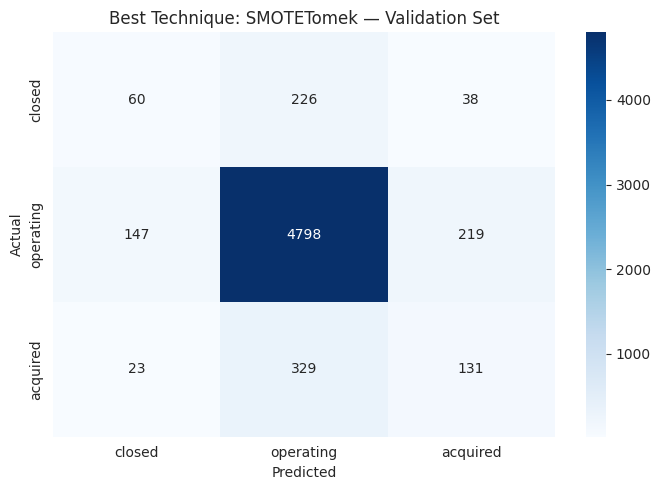

              precision    recall  f1-score   support

      closed       0.26      0.19      0.22       324
   operating       0.90      0.93      0.91      5164
    acquired       0.34      0.27      0.30       483

    accuracy                           0.84      5971
   macro avg       0.50      0.46      0.48      5971
weighted avg       0.82      0.84      0.83      5971



In [ ]:
if best_name in techniques:
    X_res_b, y_res_b = techniques[best_name].fit_resample(X_train, y_train)
    best_final_model = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        random_state=RANDOM_STATE, eval_metric='mlogloss', verbosity=0
    )
    best_final_model.fit(X_res_b, y_res_b)
elif 'Class Weights' in best_name:
    best_final_model = model_weighted
else:
    best_final_model = baseline_model

y_pred_best_val = best_final_model.predict(X_val)
plot_confusion_matrix(y_val, y_pred_best_val,
                      f'Best Technique: {best_name} — Validation Set')

print(classification_report(y_val, y_pred_best_val, target_names=STATUS_NAMES))


## Summary

| Output file | Description |
|-------------|-------------|
| `data/train_resampled.csv` | Resampled training set (best technique) |
| `data/val_processed.csv` | Validation set — unchanged from `03_Preprocessing` |
| `data/test_processed.csv` | Test set — unchanged from `03_Preprocessing` |

**Next step → `05_Modeling.ipynb`:** Load `train_resampled.csv` for model training and use `val_processed.csv` for hyperparameter tuning.